rwm ablation

In [1]:
from models.rvm_tf import RecurrentWorldModel
import yaml
import torch
import numpy as np
import cv2
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pca_vis import  *


In [2]:
_M = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
_S = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def preprocess(x, size=224):
    """(N,3,H,W) uint8 -> (N,3,size,size) normalized float32."""
    x = x.float() / 255.0
    if x.shape[-2:] != (size, size):
        x = F.interpolate(x, size=(size, size), mode="bicubic", align_corners=False)
    return (x - _M.to(x.device)) / _S.to(x.device)

In [3]:
config = yaml.safe_load(open("/home/rvm/configs/train_ema.yaml"))
model = RecurrentWorldModel(**config['model'])
checkpoint = torch.load("/home/rvm/checkpoints/checkpoints_rwm/exp_1787124491.011608/model_epoch2_step10000.pth")
model.load_state_dict(checkpoint['model'])

/root/miniconda3/envs/gssl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading the vision encoder from facebook/dinov2-small


Loading weights: 100%|██████████| 223/223 [00:00<00:00, 10670.46it/s]


<All keys matched successfully>

data

In [4]:
video_path = 'cycling.mp4'
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print("Cannot open video")

frames = []
while True:
    ret, frame = cap.read()
    if not ret: break
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = cv2.resize(frame, (256, 256))
    frames.append(frame)    

print(len(frames))
stride = 2                                   # inside [1, max_stride]
frames = frames[int(0.2 * len(frames)):][::stride]

print(len(frames))


307
123


In [5]:
@torch.no_grad()
def tier0(pred, target, last, prev=None, drop_cls=False):
    """
    pred   (B,S,n_tok,D)  rollout output
    target (B,S,n_tok,D)  encoder feats of the S predicted frames
    last   (B,n_tok,D)    encoder feats of the LAST context frame
    prev   (B,n_tok,D)    feats of the second-to-last context frame (linear baseline)
    """
    ps = slice(0, None) if drop_cls else slice(1, None)
    p, t, l = pred[..., ps, :].float(), target[..., ps, :].float(), last[:, ps].float()
    S, P = p.shape[1], p.shape[2]
    out = {}
    for h in range(S):
        den = ((l - t[:, h]) ** 2).sum()
        row = {
            "r2": 1 - ((p[:, h] - t[:, h]) ** 2).sum() / den,
            "cos": F.cosine_similarity(p[:, h], t[:, h], dim=-1).mean(),
            "cos_pers": F.cosine_similarity(l, t[:, h], dim=-1).mean(),
            "norm_ratio": p[:, h].norm(dim=-1).mean() / t[:, h].norm(dim=-1).mean(),
        }
        if prev is not None:
            lin = l + (h + 1) * (l - prev[:, ps].float())
            row["r2_linear"] = 1 - ((lin - t[:, h]) ** 2).sum() / den
        a = F.normalize(p[:, h], dim=-1) @ F.normalize(t[:, h], dim=-1).transpose(-1, -2)
        idx = torch.arange(P, device=p.device).expand(p.shape[0], P)
        row["top1"] = (a.argmax(-1) == idx).float().mean()
        out[h + 1] = {k: float(v) for k, v in row.items()}
    return out

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
N, C = 14, 6                                    # context + rollout steps
clip = torch.from_numpy(np.array(frames[:N])).permute(0, 3, 1, 2)
clip = preprocess(clip).unsqueeze(0).to(device)   # normalize! see note below

model = model.to(device)
times = torch.arange(N, device=device).float() * stride     # if raw indices
# times = torch.arange(N, device=device).float()            # if sampled counter

out = model.rollout(context=clip[:, :C],
                    gaps=times[C:] - times[C-1:-1],
                    context_times=times[:C].unsqueeze(0))
# feats = model.encode(clip.reshape(-1, *clip.shape[2:]))
# feats = feats.view(1, N, *feats.shape[1:])

# tier0(out['pred'], feats[:, 6:], feats[:, 5], feats[:, 4])

In [7]:
out.keys()

dict_keys(['pred', 'context_memory', 'context_feat'])

frame 0: explained variance = [0.206 0.136 0.093]  (sum 0.434)
frame 1: explained variance = [0.217 0.142 0.087]  (sum 0.447)
frame 2: explained variance = [0.201 0.133 0.096]  (sum 0.430)
frame 3: explained variance = [0.185 0.143 0.093]  (sum 0.420)
frame 4: explained variance = [0.195 0.144 0.094]  (sum 0.432)
frame 5: explained variance = [0.188 0.149 0.101]  (sum 0.438)


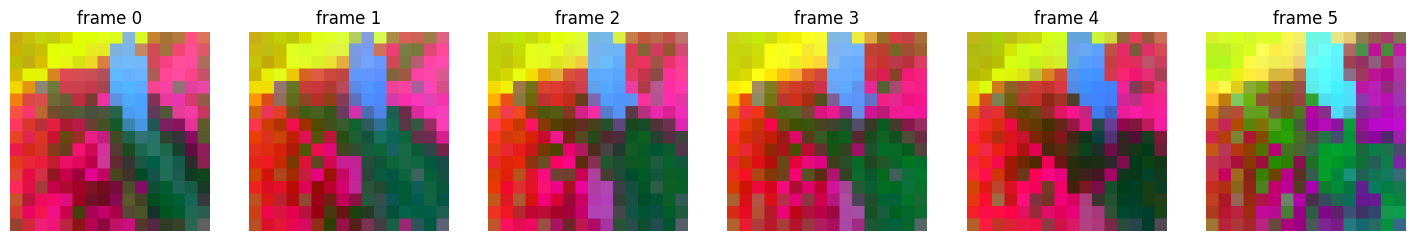

In [8]:
context_memory = out['context_feat'][..., 1:, :]
out_pca = pca_per_frame(context_memory)
context_memory_image = show(out_pca)

frame 0: explained variance = [0.243 0.165 0.107]  (sum 0.515)
frame 1: explained variance = [0.261 0.17  0.109]  (sum 0.540)
frame 2: explained variance = [0.266 0.174 0.111]  (sum 0.550)
frame 3: explained variance = [0.266 0.175 0.111]  (sum 0.552)
frame 4: explained variance = [0.266 0.176 0.111]  (sum 0.553)
frame 5: explained variance = [0.268 0.176 0.111]  (sum 0.554)
frame 6: explained variance = [0.269 0.176 0.11 ]  (sum 0.555)
frame 7: explained variance = [0.271 0.176 0.11 ]  (sum 0.557)


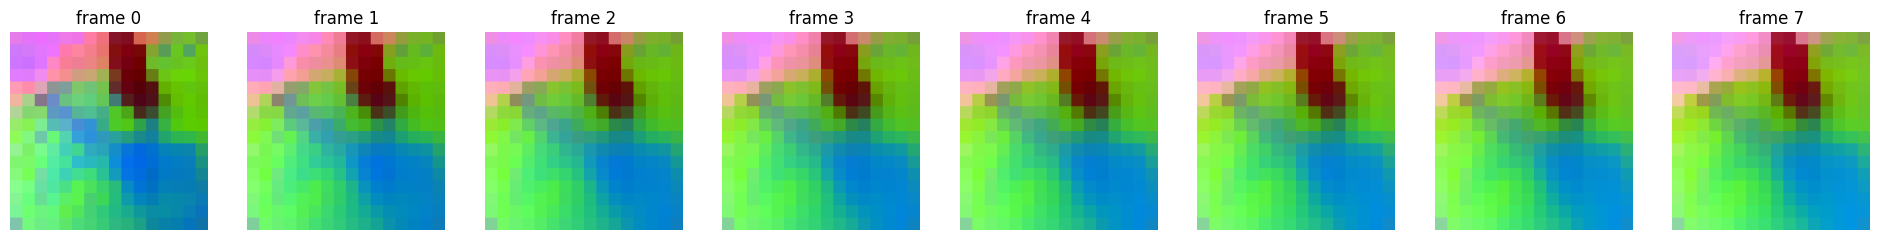

In [9]:
predicted_latents = out['pred'][..., 1:, :]
out_pca = pca_per_frame(predicted_latents)
predicted_latents_image = show(out_pca)

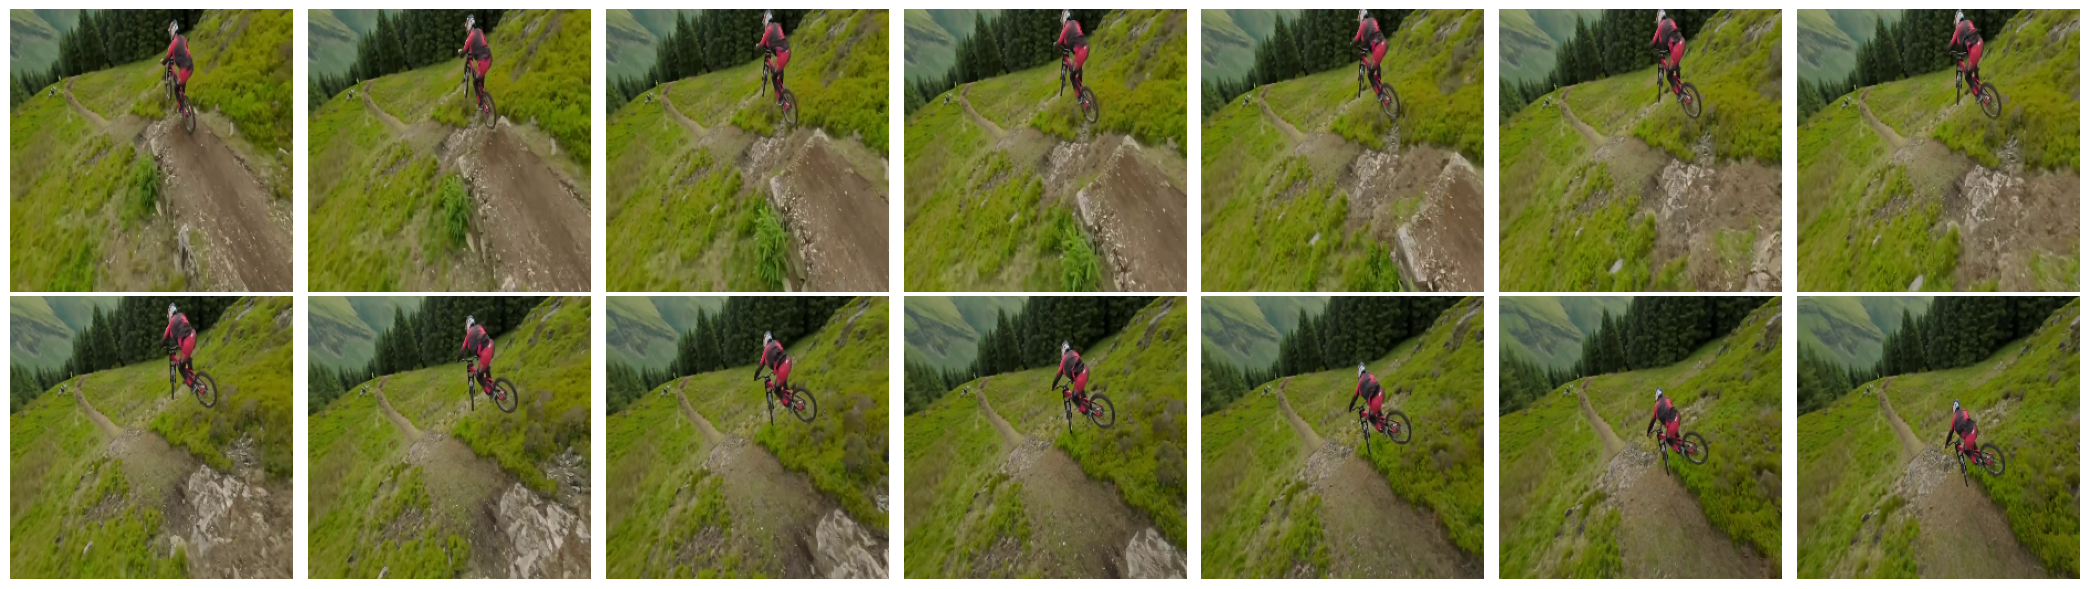

In [10]:
import math
import matplotlib.pyplot as plt

target_images = frames[:N]

n = len(target_images)
ncols = math.ceil(n / 2)
nrows = 2 if n > 1 else 1

fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 6))

axes = [axes] if n == 1 else axes.flatten()

for ax in axes:
    ax.axis("off")

for ax, img in zip(axes, target_images):
    ax.imshow(img)

plt.tight_layout()

frame 0: explained variance = [0.302 0.153 0.12 ]  (sum 0.576)
frame 1: explained variance = [0.319 0.156 0.126]  (sum 0.601)
frame 2: explained variance = [0.324 0.157 0.128]  (sum 0.610)
frame 3: explained variance = [0.324 0.158 0.128]  (sum 0.610)
frame 4: explained variance = [0.324 0.158 0.128]  (sum 0.609)
frame 5: explained variance = [0.324 0.158 0.127]  (sum 0.609)
frame 6: explained variance = [0.325 0.158 0.126]  (sum 0.609)
frame 7: explained variance = [0.325 0.158 0.126]  (sum 0.610)
saved rvm_pca.png


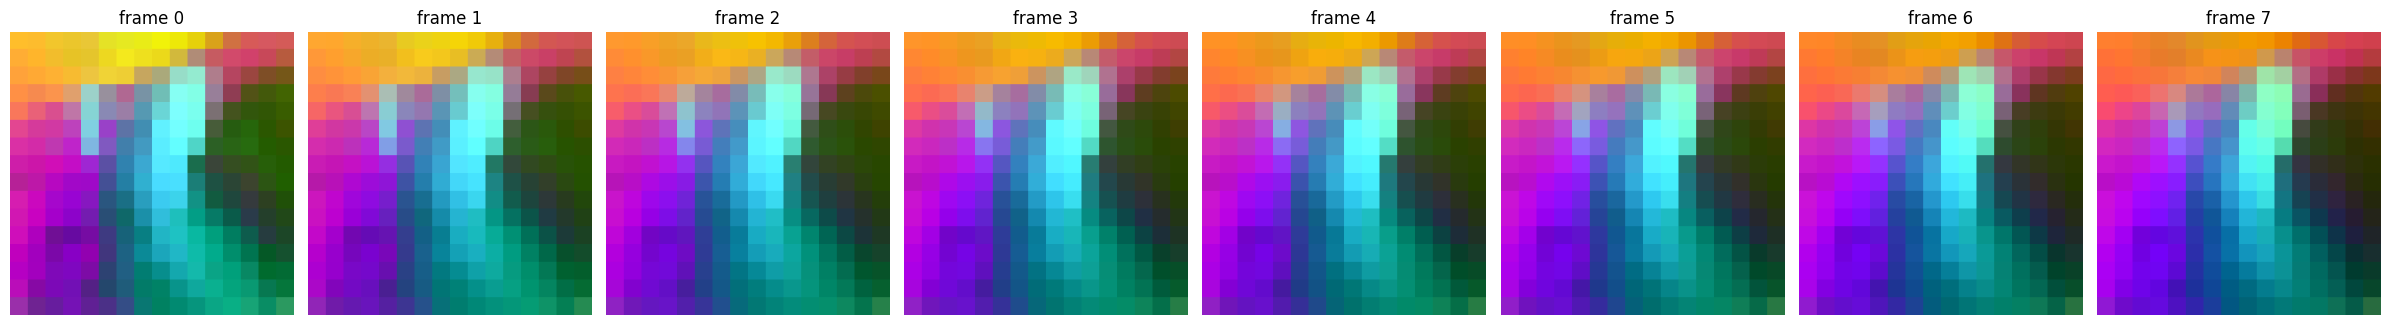

In [ ]:
predicted_latents = out['pred'][..., 1:, :]
out = pca_per_frame(predicted_latents)
image = show(out)

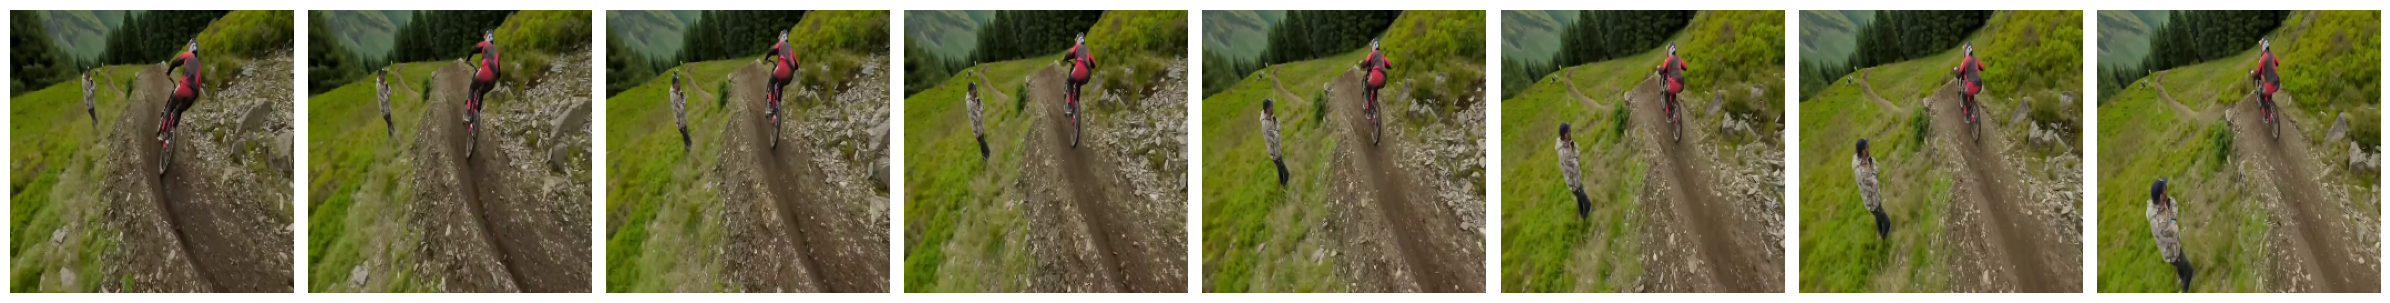

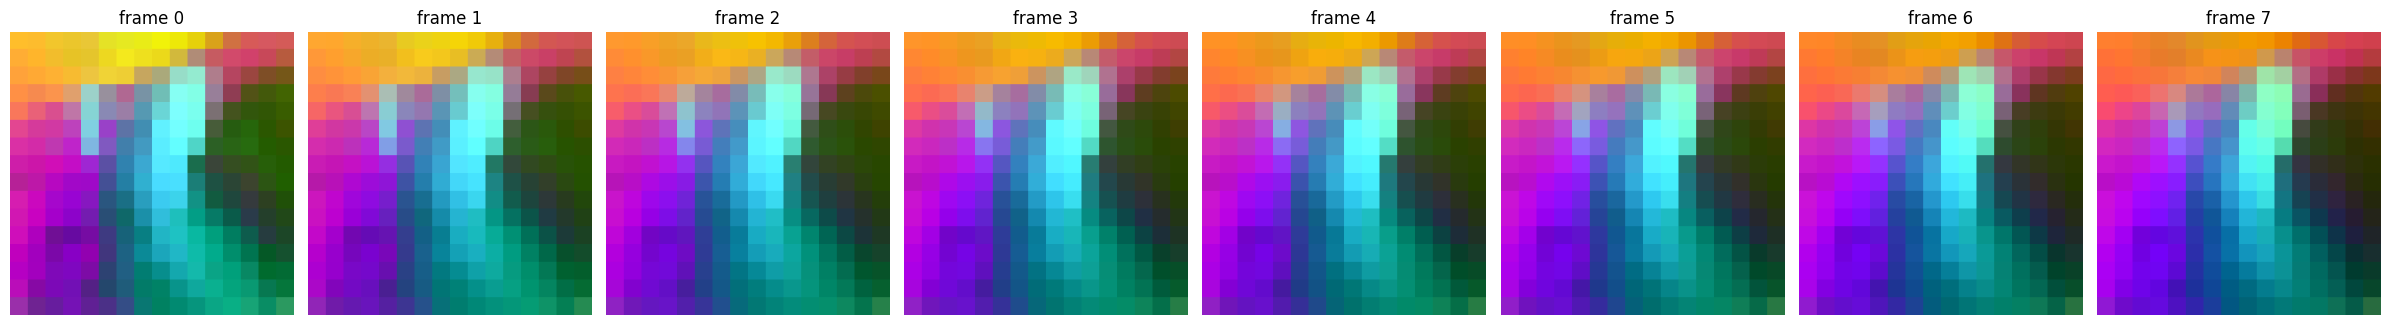

In [ ]:


target_images = frames[C:N]

fig, axes = plt.subplots(1, 8, figsize=(24, 6))

for ax, img in zip(axes, target_images):
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

image

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [ ]:
out['pred'].shape

torch.Size([1, 8, 257, 384])

In [ ]:
cf = out['context_feat'][:, -1, 1:]          # last context frame
for h in range(8):
    p = out['pred'][:, h, 1:]
    print(h+1,
          F.cosine_similarity(p, cf, dim=-1).mean().item(),      # vs. copy
          F.cosine_similarity(p, feats[:, 6+h, 1:], dim=-1).mean().item())  # vs. truth

1 0.956990122795105 0.9141736030578613
2 0.935356855392456 0.8654402494430542
3 0.9221339821815491 0.8127821683883667
4 0.9157277345657349 0.7840402722358704
5 0.9096994400024414 0.7601351737976074
6 0.9030168056488037 0.720105767250061
7 0.8938035368919373 0.6802124977111816
8 0.8837392330169678 0.6674703359603882


In [ ]:
c = out['context_feat'][:, -1, 1:].float()
for h in range(8):
    dp = out['pred'][:, h, 1:].float() - c
    dt = feats[:, 6+h, 1:].float() - c
    print(h+1,
          round(F.cosine_similarity(dp, dt, dim=-1).mean().item(), 4),
          round((dp.norm(dim=-1) / dt.norm(dim=-1)).mean().item(), 3),
          round(((dp*dt).sum() / (dp*dp).sum()).item(), 3))   # optimal alpha

1 0.3936 0.711 0.897
2 0.4362 0.635 0.966
3 0.4419 0.611 0.957
4 0.4457 0.61 0.95
5 0.4366 0.608 0.911
6 0.4207 0.606 0.867
7 0.4054 0.591 0.824
8 0.3883 0.628 0.744


In [ ]:
from transformers import AutoModel
model_name = 'facebook/dinov2-with-registers-small'
model = AutoModel.from_pretrained(model_name)




Loading weights: 100%|██████████| 224/224 [00:00<00:00, 6337.56it/s]


In [ ]:
import torch

image = torch.randn((1, 3, 256))

In [ ]:
model.config

Dinov2WithRegistersConfig {
  "apply_layernorm": true,
  "architectures": [
    "Dinov2WithRegistersModel"
  ],
  "attention_probs_dropout_prob": 0.0,
  "drop_path_rate": 0.0,
  "dtype": "float32",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 384,
  "image_size": 518,
  "initializer_range": 0.02,
  "interpolate_antialias": true,
  "interpolate_offset": 0.0,
  "layer_norm_eps": 1e-06,
  "layerscale_value": 1.0,
  "mlp_ratio": 4,
  "model_type": "dinov2_with_registers",
  "num_attention_heads": 6,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "num_register_tokens": 4,
  "out_features": [
    "stage12"
  ],
  "out_indices": [
    12
  ],
  "patch_size": 14,
  "qkv_bias": true,
  "reshape_hidden_states": true,
  "stage_names": [
    "stem",
    "stage1",
    "stage2",
    "stage3",
    "stage4",
    "stage5",
    "stage6",
    "stage7",
    "stage8",
    "stage9",
    "stage10",
    "stage11",
    "stage12"
  ],
  "transformers_version": "5.15.1",
  "use_swigl

In [ ]:
model.config.num_register_tokens

4

In [ ]:
output = model(image)

ValueError: not enough values to unpack (expected 4, got 3)

In [ ]:
output['last_hidden_state'].shape

torch.Size([1, 261, 384])

In [ ]:
261-5

256

In [ ]:
from rvm import RVM

In [ ]:
model = RVM()

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

In [ ]:
model

RVM(
  (encoder): Dinov2Model(
    (embeddings): Dinov2Embeddings(
      (patch_embeddings): Dinov2PatchEmbeddings(
        (projection): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): Dinov2Encoder(
      (layer): ModuleList(
        (0-11): 12 x Dinov2Layer(
          (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True, bias=True)
          (attention): Dinov2Attention(
            (attention): Dinov2SelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
            )
            (output): Dinov2SelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (layer_scale1): Dinov2LayerScale()
    

In [ ]:
import torch
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import requests

url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw)

processor = AutoImageProcessor.from_pretrained('facebook/dinov2-small')
model = AutoModel.from_pretrained('facebook/dinov2-small')

inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs)

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

In [ ]:
patchify = model.embeddings
encoder = model.encoder

In [ ]:
import cv2

image = cv2.imread("/home/mahesh/rvm/images/55e65115bd86ef19008b76e5.jpeg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image.shape

(453, 604, 3)

In [ ]:
inputs

{'pixel_values': tensor([[[[ 0.2967,  0.4679,  0.4508,  ..., -0.6794, -0.4911, -0.4568],
          [ 0.3309,  0.4337,  0.3309,  ..., -0.6452, -0.6281, -0.5938],
          [ 0.3309,  0.3823,  0.3309,  ..., -0.9363, -0.8849, -0.8335],
          ...,
          [ 1.9749,  2.0434,  1.9235,  ...,  1.9920,  2.0948,  2.0263],
          [ 1.8893,  2.0263,  2.0434,  ...,  2.0263,  2.0092,  2.0434],
          [ 1.9407,  2.0434,  1.9407,  ...,  2.0777,  2.0263,  2.0092]],

         [[-1.5455, -1.4930, -1.5455,  ..., -1.8081, -1.7906, -1.7381],
          [-1.5280, -1.4755, -1.5980,  ..., -1.8081, -1.8081, -1.7906],
          [-1.5630, -1.5280, -1.4755,  ..., -1.8957, -1.8782, -1.8606],
          ...,
          [-0.5476, -0.4776, -0.5826,  ..., -0.4601, -0.4076, -0.4951],
          [-0.6702, -0.5826, -0.6176,  ..., -0.4601, -0.5126, -0.5301],
          [-0.6527, -0.4601, -0.6352,  ..., -0.5126, -0.4076, -0.5301]],

         [[-0.6367, -0.4973, -0.5321,  ..., -1.3339, -1.2467, -1.1770],
          [-0

In [ ]:
image = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).float() / 255.0
inputs = processor(images=image, return_tensors="pt")

In [ ]:
embeddings = patchify(image)
output = encoder(embeddings)

In [ ]:
output

BaseModelOutput(last_hidden_state=tensor([[[ 0.5233, -0.0787,  0.9856,  ...,  0.6434, -0.3035, -0.1449],
         [ 0.5041, -0.2568, -0.3217,  ...,  0.1732,  1.1817,  0.0131],
         [ 0.9982, -0.4383, -0.5658,  ...,  0.1470,  0.9207, -0.0328],
         ...,
         [ 0.5967, -0.0599,  0.3916,  ...,  0.1090, -1.7303, -0.7095],
         [ 0.6670,  0.1371,  1.2471,  ...,  0.7294, -0.6459, -0.7960],
         [ 0.6564,  0.1411,  0.6895,  ...,  0.6448, -0.7452, -0.9086]]],
       grad_fn=<AddBackward0>), hidden_states=None, attentions=None)

In [ ]:
image.shape

torch.Size([1, 3, 453, 604])

In [ ]:
model(image)

BaseModelOutputWithPooling(last_hidden_state=tensor([[[ 2.1510, -2.1019,  2.9470,  ...,  2.5055, -1.4837, -2.0446],
         [ 1.2393, -4.3554, -1.7489,  ...,  0.2550,  2.3081, -0.9307],
         [ 2.4849, -6.6541, -2.3789,  ...,  0.1781,  1.7016, -1.2444],
         ...,
         [ 1.7188, -1.1699,  0.2248,  ...,  0.2890, -4.6087, -5.0530],
         [ 1.5378,  0.3058,  1.8920,  ...,  1.5495, -1.8941, -5.4217],
         [ 1.5715,  0.4897,  0.6832,  ...,  1.4086, -2.1315, -6.1235]]],
       grad_fn=<NativeLayerNormBackward0>), pooler_output=tensor([[ 2.1510, -2.1019,  2.9470,  1.4189, -3.5443,  2.7179,  0.2338, -0.3361,
         -1.9632,  1.5794, -5.2298,  2.2831, -3.6713, -0.8294,  6.1778, -0.8654,
         -0.6508, -0.1798,  1.4968, -2.1632,  1.6823, -0.1358, -2.2938,  0.5821,
          2.1957, -3.6241, -0.1704,  1.9996, -2.2006,  0.9956,  2.6592, -1.0590,
         -0.8674, -3.7834, -0.3068,  3.6649,  1.7458,  1.7687, -1.9666,  1.4142,
         -5.4779,  1.9992,  0.6973,  3.3112,  2.71